# Assignment 1 
## Questions:
The objective of this assignment is to explore the survey data to understand (1) the nature of women’s representation in Data Science and Machine Learning and (2) the effects of education on income level. The following tasks should be completed:

Importing the needed packages:

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
try:
    import pingouin as pg
except:
    !pip install pingouin
    import pingouin as pg
%matplotlib inline

Print the version of Python:

In [2]:
import sys 
print(sys.version)

3.9.13 (main, Aug 25 2022, 23:51:50) [MSC v.1916 64 bit (AMD64)]


Reading the data:

In [3]:
url = "clean_kaggle_data.csv"
df = pd.read_csv(url,low_memory=False)
df.shape

(15391, 370)

## Question 1.
Perform exploratory data analysis to analyze the survey dataset and to summarize its main characteristics. Present 3 graphical figures that represent different trends in the data. For your explanatory data analysis, you can consider Country, Age, Education, Professional Experience, and Salary.

#### Data exploration:
Assigning column names based on kaggle_survey_2021_answer_choices.pdf:

In [4]:
adf = df[['Q1', 'Q2', 'Q4', 'Q25']]
adf = adf.rename(columns={'Q1': 'age', 'Q2': 'gender', 'Q4': 'degree', 'Q25': 'salary'})
adf.head()

,age,gender,degree,salary
0,50-54,Man,Bachelor’s degree,30000
1,50-54,Man,Master’s degree,70000
2,22-24,Man,Master’s degree,1000
3,45-49,Man,Doctoral degree,40000
4,45-49,Man,Doctoral degree,40000


#### Computing descriptive statistics:
Reorganizing the answers to Q7:

In [5]:
names = ['Q7_Part_'+str(i+1) for i in range(12)]
names = names + ['Q7_OTHER']
lan = df[names].describe()
# Each column has one unique element
lan = pd.Series(lan.loc['count'].values, lan.loc['top'].values, name='count')
lan = pd.DataFrame(lan)
lan

,count
Python,12467
R,3406
SQL,7098
C,2036
C++,2490
Java,2480
Javascript,2574
Julia,197
Swift,173
Bash,1677


In [6]:
cat = adf[['age', 'gender', 'degree']]
cat.describe()

,age,gender,degree
count,15391,15391,15391
unique,11,5,7
top,25-29,Man,Master’s degree
freq,3235,12642,6799


In [7]:
salary = adf[['salary']]
salary.describe()

,salary
count,15391.000000
mean,49116.009356
std,98090.207788
min,1000.000000
25%,2000.000000
50%,15000.000000
75%,60000.000000
max,1000000.000000


### Education:
Both pie chart and bar chart may be used to explore categorical data. Here, pie chart is used to visualize the “highest level of formal education:

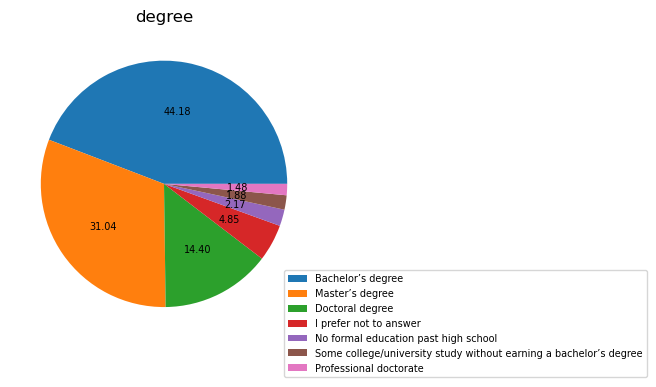

In [8]:
degree = cat['degree'].unique()
n = len(degree)
labels = ['' for _ in range(n)]
cat['degree'].value_counts().plot(kind='pie', ylabel='', title='degree', 
                                  autopct='%.2f', labels=labels, fontsize=7, figsize = (10,4))
plt.legend(degree, fontsize=7, bbox_to_anchor=(1,0), 
           loc="lower right", bbox_transform=plt.gcf().transFigure)
plt.show()

### Age groups:
Age groupes may be treated as either categorical data or binned quantitative data. For the current data, the bin ranges are as follows:<br>
\begin{align}
[18, 22) && [22, 25) &&[25, 30) &&[30, 35) && [35, 40) &&[40, 45)\\
[45, 50) &&[50, 55) && [55, 60) &&[60, 70) && [70, \infty)
\end{align}

Rearranging the bins:

In [9]:
age = cat['age'].value_counts()
grs = age.index.tolist()
bins = age.index.str.split('+').tolist()
bins = [j for i in bins for j in i]
bins = list(filter(None, bins))
bins = [i.split('-') for i in bins]
bins = [[int(j) for j in i] for i in bins]
count = pd.Series.tolist(age)
tuples = list(zip(bins, grs, count))
pd.DataFrame(tuples, columns=['bins', 'age groups', 'count'])

,bins,age groups,count
0,"[25, 29]",25-29,3235
1,"[30, 34]",30-34,2626
2,"[22, 24]",22-24,2092
3,"[35, 39]",35-39,1992
4,"[40, 44]",40-44,1528
5,"[45, 49]",45-49,1141
6,"[18, 21]",18-21,931
7,"[50, 54]",50-54,791
8,"[55, 59]",55-59,504
9,"[60, 69]",60-69,454


The distribution of the age groups is visualized using both bar chart and histogram plot.

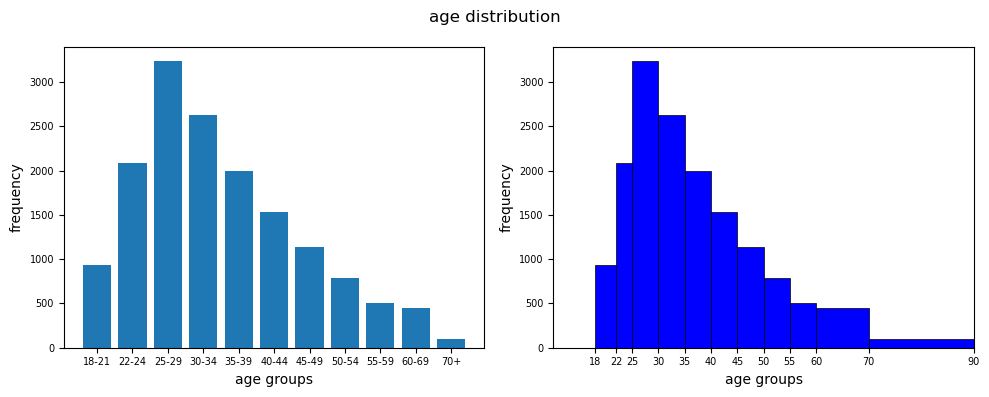

In [10]:
upp = 90
# Bins for hist
bins = [min(i) for i in bins]
# Ordering the bins
tuples = zip(*sorted(zip(bins, count, grs)))
bins, count, grs = [list(i) for i in  tuples]
fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax[0].bar(grs, count)
ax[1].hist(bins, bins=bins+[upp], weights=count, color='blue', edgecolor='black', linewidth=0.5)
ax[1].set_xlim(xmin=10, xmax=upp)
ax[1].set_xticks(bins+[upp])
for i in [0, 1]:
    ax[i].tick_params(axis='both', labelsize=7)
    ax[i].set_xlabel('age groups')
    ax[i].set_ylabel('frequency')
fig.suptitle('age distribution')
plt.tight_layout()
plt.show()

### Programming languages:

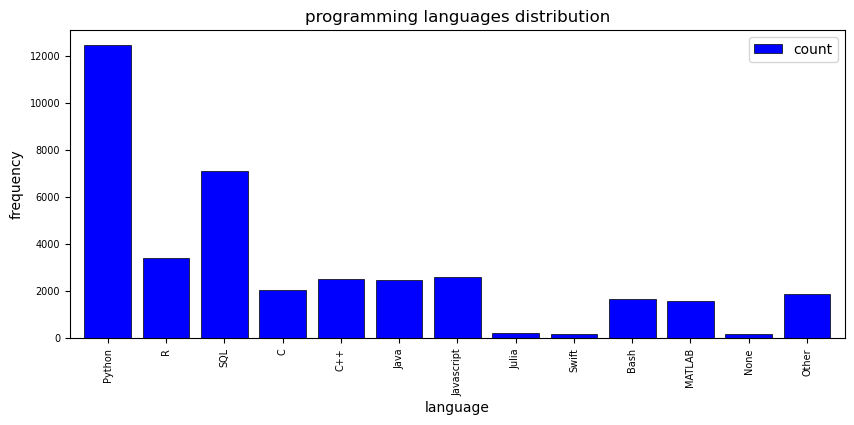

In [11]:
lan.plot.bar(width=0.8, xlabel='language', ylabel='frequency', title='programming languages distribution', 
             color='blue', edgecolor='black', linewidth=0.5, fontsize=7, figsize=(10,4))
plt.show()

### Yearly compensation:

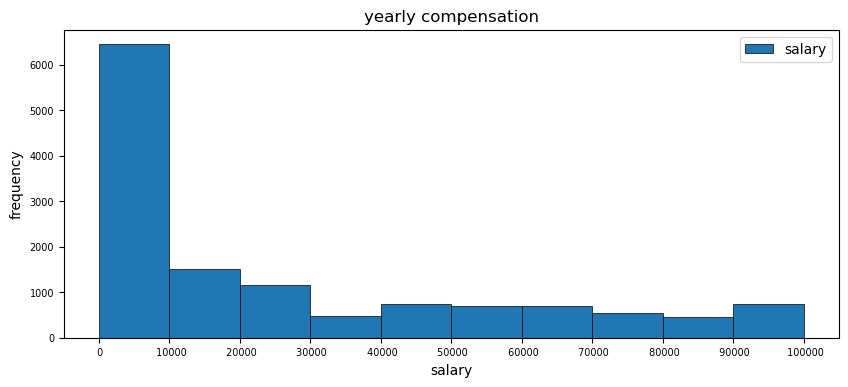

In [12]:
bins = np.linspace(0, 100000, num=11)
salary.plot.hist(bins=bins, figsize = (10,4), title='yearly compensation', 
                 edgecolor='black', linewidth=0.5, fontsize=7)
ax = plt.gca()
ax.set_xticks(bins)
ax.xaxis.set_major_formatter("{x: .0f}")
ax.set_xlabel('salary')
ax.set_ylabel('frequency')
plt.show()

## Question 2.
Estimating the difference between average salary (Q25) of men vs. women (Q2).
1. Compute and report descriptive statistics for each group (remove missing data, if necessary).
2. If suitable, perform a two-sample t-test with a 0.05 threshold. Explain your rationale.
3. Bootstrap your data for comparing the mean of salary (Q25) for the two groups. Note that the number of instances you sample from each group should be relative to its size. Use 1000 replications. Plot two bootstrapped distributions (for men and women) and the distribution of the difference in means.
4. If suitable, perform a two-sample t-test with a 0.05 threshold on the bootstrapped data. Explain your rationale.
5. Comment on your findings.

In [13]:
from scipy import stats as st

#### Computing descriptive statistics:
Computing means of `salary` for gender groups:

Calculating descriptive statistics for `salary` of female population:

In [14]:
female_salary = adf[adf['gender'] == 'Woman']['salary'].dropna()
Nx = female_salary.count()
female_salary.describe()

count       2482.000000
mean       34816.881547
std        72017.347888
min         1000.000000
25%         1000.000000
50%         7500.000000
75%        50000.000000
max      1000000.000000
Name: salary, dtype: float64

Calculating descriptive statistics for `salary` of male population:

In [15]:
male_salary = adf[adf['gender'] == 'Man']['salary'].dropna()
Ny = male_salary.count()
male_salary.describe()

count      12642.000000
mean       51193.600696
std        99979.274378
min         1000.000000
25%         2000.000000
50%        20000.000000
75%        60000.000000
max      1000000.000000
Name: salary, dtype: float64

#### Hypothesis testing (independent samples t-test)

The assumptions for independent t-test are as follows:
1. Data values must be independent.
2. Data in each group are normally distributed.
3. The variances for the two independent groups are equal.

We have seen above that the mean `salary` for the male and female populations was different. Based on the central limit theorem, the distribution of the means approximates the normal distribution for large enough samples sizes.

Homogeneity of variance (HOV) may not be satisfied, especially since the male sample size is 5 times larger than the female sample size. The HOV assumption is evaluated using Levene's test with `scipy.stats.levene()`:

In [16]:
lev, pl = st.levene(female_salary, male_salary)
print ("Levene's-test: stat = %g  p = %g" % (lev, pl))

Levene's-test: stat = 47.0172  p = 7.30941e-12


Hence, the difference in the variances is statistically significant (`p-value = 7.3e-12 < 0.05`). Welch’s t-test does not require the HOV condition and is used here instead of Student’s t-test:

In [17]:
tc, pc = st.ttest_ind(female_salary, male_salary, equal_var = False)
print ("t-test: t = %g  p = %g" % (tc, pc))

t-test: t = -9.64952  p = 7.95292e-22


In the case of the mean salary, it is concluded that men tend to have a higher income (`p-value = 8e-22 < 0.05`, statistically significant).

#### Bootstrapping:
Here, the number of instances used to sample each group is equal to its size. 1000 replications were used to obtain the bootstrapped distributions and the distribution of the difference in means.

In [18]:
x = []
y = []
dif = []
N_resample = 1000
for _ in range(N_resample):
    x_sample = np.random.choice(female_salary, size=Nx, replace=True)
    x.append(x_sample.mean())
    y_sample = np.random.choice(male_salary, size=Ny, replace=True)
    y.append(y_sample.mean())
    dif.append(y_sample.mean()-x_sample.mean())

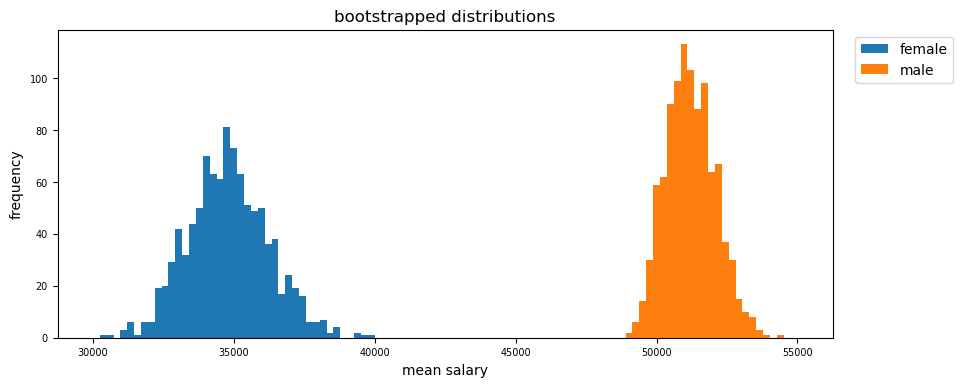

In [19]:
plt.figure(figsize=(10,4))
plt.rc('xtick', labelsize=7)
plt.rc('ytick', labelsize=7)
plt.hist(x, bins=41, range=[30000, 40000])
plt.hist(y, bins=41, range=[45000, 55000])
plt.title('bootstrapped distributions')
plt.xlabel('mean salary')
plt.ylabel('frequency')
plt.legend(['female', 'male'], bbox_to_anchor=(1.02, 1.0), loc='upper left')
plt.show()

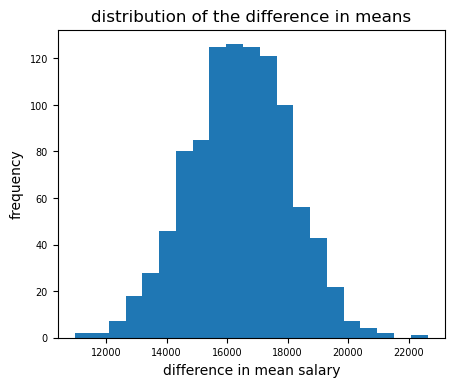

In [20]:
plt.figure(figsize=(5,4))
plt.title('distribution of the difference in means')
plt.xlabel('difference in mean salary')
plt.ylabel('frequency')
plt.hist(dif, bins=21)
plt.show()

Calculating the confidence interval for the difference in the means:

In [21]:
conf_int = np.percentile(np.sort(dif), [2.5, 97.5])
print("The 95 % confidence interval is: ", conf_int)

The 95 % confidence interval is:  [13099.59865198 19475.47597806]


The confidence interval analysis shows that the difference in mean is significant.

To check for homogeneity of variance, Levene's test with `scipy.stats.levene()` is used. Note that Bartlett and F-test may also be used since the distribution of the means is normal according to the central limit theorem:

In [22]:
lev, pl = st.levene(x, y)
print ("Levene's-test: stat = %g  p = %g" % (lev, pl))

Levene's-test: stat = 176.53  p = 1.15164e-38


It is concluded that the difference in the variances is statistically significant (`p-value = 2.5e-41 < 0.05`). Therefore, Student's t-test may not be reliable and Welch's t-test should be used to compare the means of the two groups.

In [23]:
tc, pc = st.ttest_ind(x, y, equal_var = False)
print ("t-test: t = %g  p = %g" % (tc, pc))

t-test: t = -308.354  p = 0


Again, it is concluded that men tend to have a higher income (`p-value = 0 < 0.05`, statistically significant).

## Question 3.
Select “highest level of formal education” (Q4) from the dataset and repeat steps 1 to 5. This time use analysis of variance (ANOVA) instead of t-test for hypothesis testing to compare the means of salary for three groups (Bachelor’s degree, Master’s degree, and Doctoral degree)

#### Computing descriptive statistics:
Computing means of `salary` for the three groups:

In [24]:
data = adf[['degree','salary']]
degree_data = adf.groupby('degree')
print(degree_data.mean())

                                                          salary
degree                                                          
Bachelor’s degree                                   35578.291815
Doctoral degree                                     70641.181777
I prefer not to answer                              34191.616766
Master’s degree                                     52706.868657
No formal education past high school                38208.333333
Professional doctorate                              67465.517241
Some college/university study without earning a...  41990.616622


Calculating descriptive statistics for `salary` of female population:

In [25]:
BS_salary = adf[adf['degree'] == 'Bachelor’s degree']['salary'].dropna()
Nx = BS_salary.count()
BS_salary.describe()

count       4777.000000
mean       35578.291815
std        89382.060777
min         1000.000000
25%         1000.000000
50%         7500.000000
75%        40000.000000
max      1000000.000000
Name: salary, dtype: float64

In [26]:
MS_salary = adf[adf['degree'] == 'Master’s degree']['salary'].dropna()
Ny = MS_salary.count()
MS_salary.describe()

count       6799.000000
mean       52706.868657
std        90928.786678
min         1000.000000
25%         3000.000000
50%        25000.000000
75%        70000.000000
max      1000000.000000
Name: salary, dtype: float64

In [27]:
PHD_salary = adf[adf['degree'] == 'Doctoral degree']['salary'].dropna()
Nz = PHD_salary.count()
PHD_salary.describe()

count       2217.000000
mean       70641.181777
std       117160.947589
min         1000.000000
25%         4000.000000
50%        40000.000000
75%        90000.000000
max      1000000.000000
Name: salary, dtype: float64

#### Hypothesis testing (one-way ANOVA)

The assumptions for one-way ANOVA are as follows:
1. Data values must be independent.
2. Data in each group are normally distributed.
3. The variances for the two independent groups are equal.

We have seen above that the mean `salary` for the three groups was different. Parametric tests of the mean are robust to departures from the normality according to the central limit theorem. In ANOVA, when homogeneity of variance is violated, there is a greater probability of falsely rejecting the null hypothesis. To check for homogeneity of variance, Levene's test with `scipy.stats.levene()` is performed:

In [28]:
lev, pl = st.levene(BS_salary, MS_salary, PHD_salary)
print ("Levene's-test: stat = %g  p = %g" % (lev, pl))

Levene's-test: stat = 79.5475  p = 4.47424e-35


Since difference in the variances is statistically significant (`p-value = 4.47-35 < 0.05`). Therefore, ANOVA may not be reliable, and consequently, Welch's ANOVA with `pingouin.welch_anova()` is used to compare the means of the three groups:

In [29]:
pg.welch_anova(dv='salary', between='degree', data=adf)

,Source,ddof1,ddof2,F,p-unc,np2
0,degree,6,1295.978657,34.623387,5.932756e-39,0.015042


Hence, we can reject the null hypothesis that the yearly salary is equal between the three groups (`p-value = 5.9e-39 < 0.05`).

#### Bootstrapping:
Here, the number of instances used to sample each group is equal to its size. 1000 replications were used to obtain the bootstrapped distributions and the distribution of the difference in means.

In [30]:
x = []
y = []
z = []
dif_xy = []
dif_yz = []
dif_xz = []
N_resample = 1000
for _ in range(N_resample):
    x_sample = np.random.choice(BS_salary, size=Nx, replace=True)
    x.append(x_sample.mean())
    y_sample = np.random.choice(MS_salary, size=Ny, replace=True)
    y.append(y_sample.mean())
    z_sample = np.random.choice(PHD_salary, size=Nz, replace=True)
    z.append(z_sample.mean())
    dif_xy.append(y_sample.mean()-x_sample.mean())
    dif_yz.append(z_sample.mean()-y_sample.mean())
    dif_xz.append(z_sample.mean()-x_sample.mean())

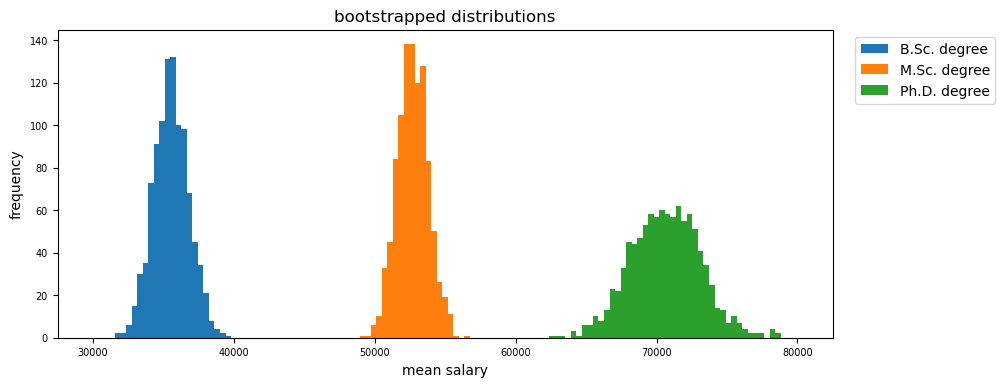

In [31]:
plt.figure(figsize=(10,4))
plt.rc('xtick', labelsize=7)
plt.rc('ytick', labelsize=7)
plt.hist(x, bins=51, range=[30000, 50000])
plt.hist(y, bins=51, range=[45000, 65000])
plt.hist(z, bins=51, range=[60000, 80000])
plt.title('bootstrapped distributions')
plt.xlabel('mean salary')
plt.ylabel('frequency')
plt.legend(['B.Sc. degree', 'M.Sc. degree', 'Ph.D. degree'], bbox_to_anchor=(1.02, 1.0), loc='upper left')
plt.show()

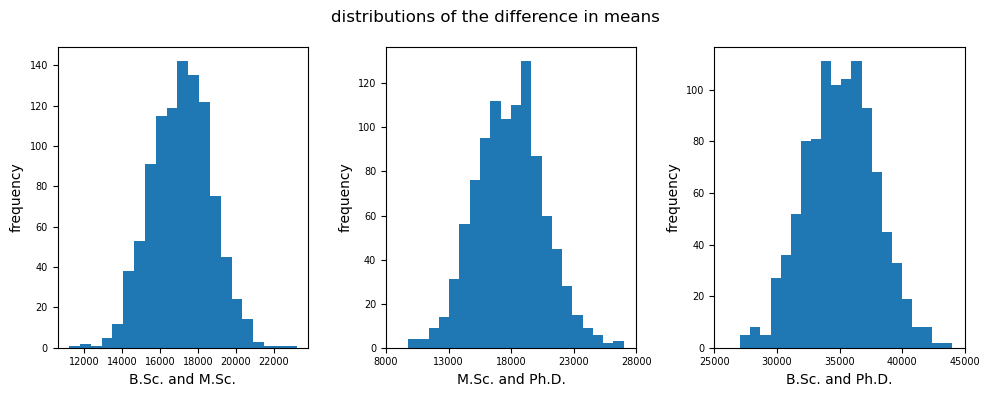

In [32]:
fig, ax = plt.subplots(1, 3, figsize=(10,4))
ax[0].hist(dif_xy, bins=21)
ax[1].hist(dif_yz, bins=21)
ax[2].hist(dif_xz, bins=21)
ax[0].set_xticks([12000+2000*i for i in range(6)])
ax[1].set_xticks([8000+5000*i for i in range(5)])
ax[2].set_xticks([25000+5000*i for i in range(5)])
ax[0].set_xlabel('B.Sc. and M.Sc.')
ax[1].set_xlabel('M.Sc. and Ph.D.')
ax[2].set_xlabel('B.Sc. and Ph.D.')
for i in range(3):
    ax[i].tick_params(axis='both', labelsize=7)
    ax[i].set_ylabel('frequency')
fig.suptitle('distributions of the difference in means')
plt.tight_layout()
plt.show()

To check for homogeneity of variance, Levene's test with `scipy.stats.levene()` is performed:

In [33]:
lev, pl = st.levene(x, y, z)
print ("Levene's-test: stat = %g  p = %g" % (lev, pl))

Levene's-test: stat = 347.98  p = 1.27112e-136


Levene's test indicates that the difference in the variances is statistically significant (`p-value = 6.4e-141 < 0.05`). Therefore, ANOVA may not be reliable and Welch's ANOVA should be used to compare the means of the three bootstrapped data:

In [34]:
bdf = pd.DataFrame({'degree': np.repeat(['Bachelor’s degree', 'Master’s degree', 'Doctoral degree'],
                                      repeats=1000), 'salary': x+y+z})
bdf.head()

,degree,salary
0,Bachelor’s degree,37146.326146
1,Bachelor’s degree,34151.873561
2,Bachelor’s degree,34957.714046
3,Bachelor’s degree,36976.554323
4,Bachelor’s degree,37328.239481


In [35]:
pg.welch_anova(dv='salary', between='degree', data=bdf)

,Source,ddof1,ddof2,F,p-unc,np2
0,degree,2,1871.209566,100499.808836,0.0,0.98573


Hence, we can reject the null hypothesis that the yearly salary is equal between the three groups (`p-value = 0.0 < 0.05`).